# Stock Market Trend Analysis — Final Integration

This notebook combines the completed Phase 4–7 summary outputs into one descriptive final view for AAPL, MSFT, GOOGL, AMZN, and NVDA.

## Objective and scope

The final integration compares historical performance, volatility, current descriptive trend classifications, and daily-return correlation findings. It does not create predictions, trading signals, investment scores, or investment recommendations.

In [1]:
from pathlib import Path
import sys
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.final_analysis import FIGURES_DIR, build_final_dataset, create_insights, load_inputs, save_figures, validate

## Data sources and final consolidated dataset

In [2]:
performance, risk, trend, correlation_pairs = load_inputs()
final_data = build_final_dataset(performance, risk, trend)
validate(final_data, correlation_pairs)
final_data.round(4)

,Stock,Initial Price,Final Price,Total Price Change,Total Price Return,Average Daily Return,Best Single-Day Return,Worst Single-Day Return,Cumulative Return,Daily Volatility,...,SMA50,SMA200,Close vs SMA200 (%),Trend Classification,Bullish Crossovers,Bearish Crossovers,Latest Crossover Date,Latest Crossover Type,Performance Rank,Risk Rank
0,AAPL,151.1200,305.93,154.8100,1.0244,0.0007,0.1533,-0.0925,1.0244,0.0177,...,309.1908,280.4836,9.0723,Mixed,16,16,2026-07-09,Bullish,3,5
1,MSFT,294.6000,495.40,200.8000,0.6816,0.0006,0.1551,-0.0999,0.6816,0.0177,...,412.7756,432.4805,14.5485,Mixed,14,13,2026-08-03,Bullish,4,4
2,GOOGL,138.3095,345.90,207.5905,1.5009,0.0009,0.1022,-0.0951,1.5009,0.0202,...,353.8944,331.3754,4.3831,Mixed,14,14,2026-06-23,Bearish,2,3
3,AMZN,164.9495,262.65,97.7005,0.5923,0.0006,0.1532,-0.1405,0.5923,0.0229,...,248.1666,237.7025,10.4953,Bullish,13,12,2026-08-04,Bullish,5,2
4,NVDA,19.9500,225.16,205.2100,10.2862,0.0025,0.2437,-0.1697,10.2862,0.0327,...,206.5196,194.9198,15.5142,Bullish,15,14,2026-08-06,Bullish,1,1


## Performance comparison

,Stock,Total Price Return,Performance Rank
4,NVDA,10.2862,1
2,GOOGL,1.5009,2
0,AAPL,1.0244,3
1,MSFT,0.6816,4
3,AMZN,0.5923,5


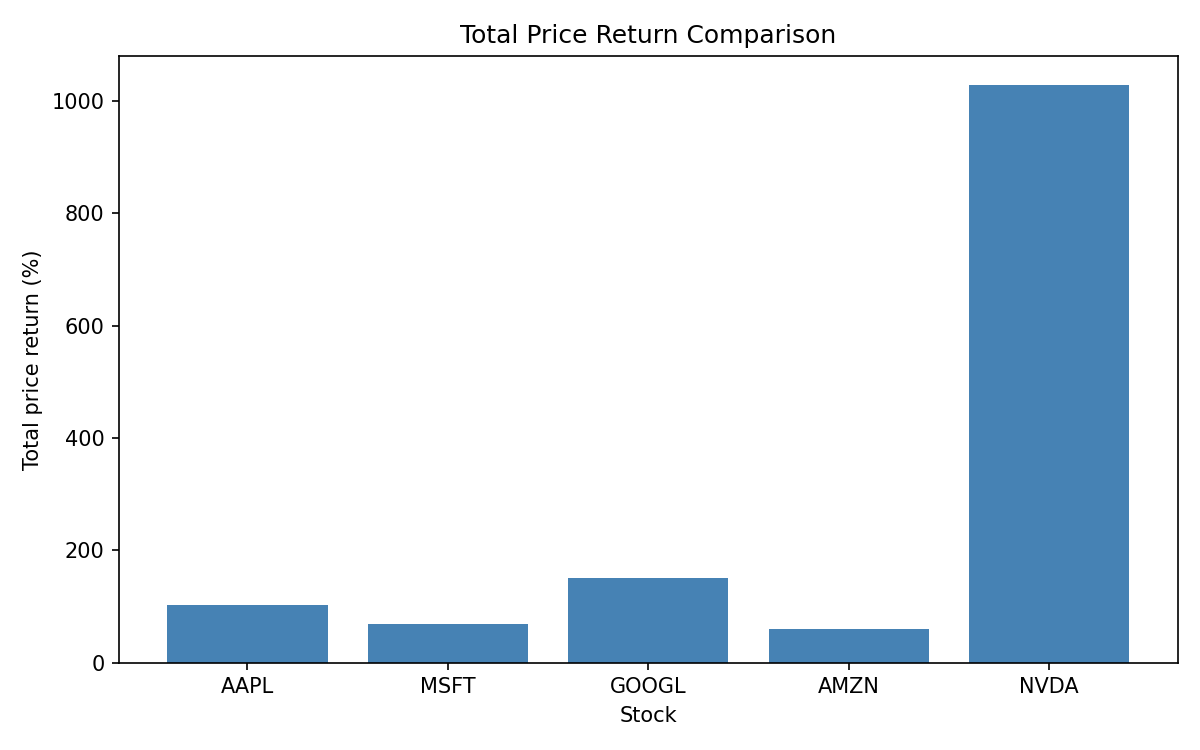

In [3]:
display(final_data[['Stock', 'Total Price Return', 'Performance Rank']].sort_values('Performance Rank').round(4))
save_figures(final_data)
display(Image(filename=str(FIGURES_DIR / 'final_performance_comparison.png')))

## Risk comparison

,Stock,Annualized Volatility,Risk Rank
4,NVDA,0.5194,1
3,AMZN,0.3639,2
2,GOOGL,0.3212,3
1,MSFT,0.2815,4
0,AAPL,0.2804,5


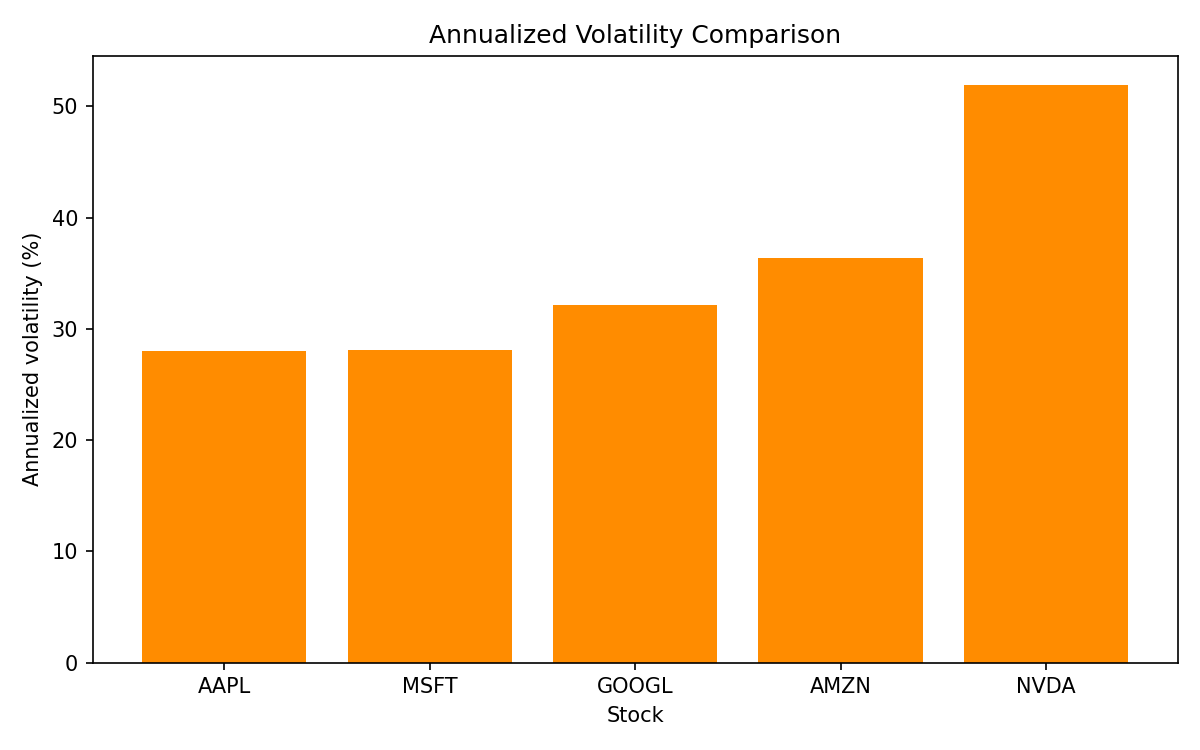

In [4]:
display(final_data[['Stock', 'Annualized Volatility', 'Risk Rank']].sort_values('Risk Rank').round(4))
display(Image(filename=str(FIGURES_DIR / 'final_risk_comparison.png')))

## Risk vs performance

,Stock,Annualized Volatility,Total Price Return
0,AAPL,0.2804,1.0244
1,MSFT,0.2815,0.6816
2,GOOGL,0.3212,1.5009
3,AMZN,0.3639,0.5923
4,NVDA,0.5194,10.2862


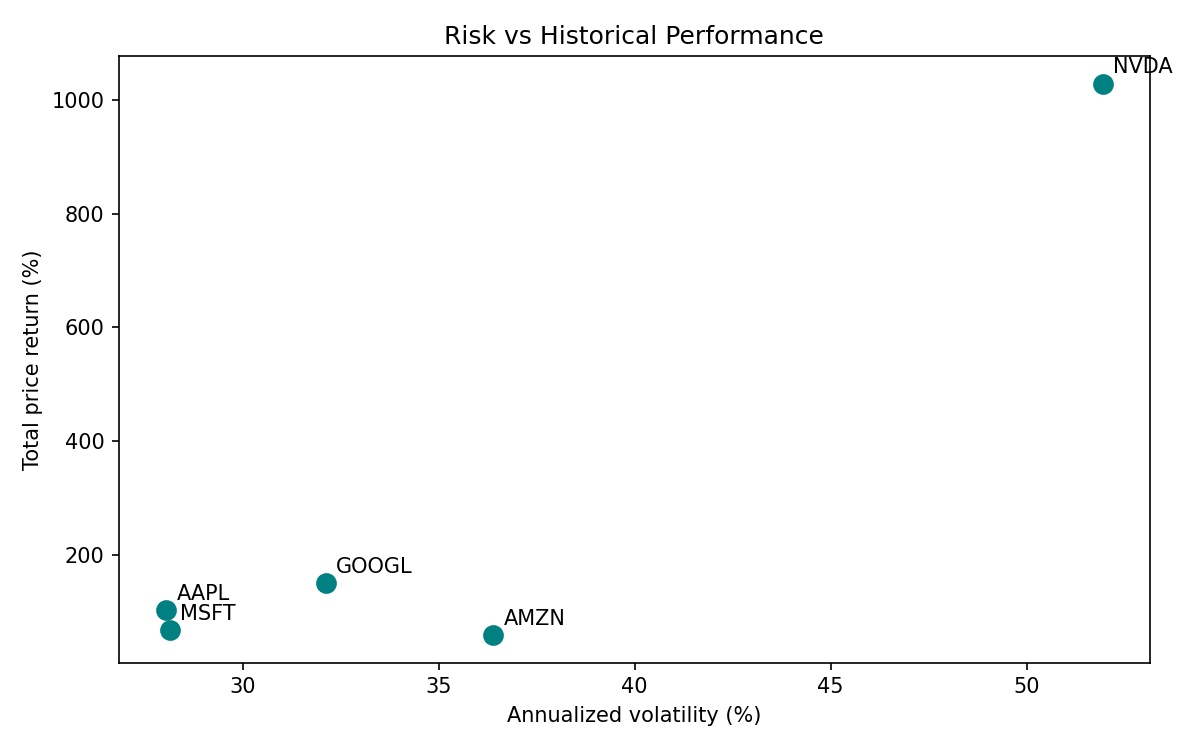

In [5]:
display(final_data[['Stock', 'Annualized Volatility', 'Total Price Return']].round(4))
display(Image(filename=str(FIGURES_DIR / 'final_risk_vs_performance.png')))

## Current trend summary

In [6]:
trend_columns = ['Stock', 'Trend Classification', 'Latest Close', 'SMA20', 'SMA50', 'SMA200', 'Close vs SMA200 (%)']
final_data[trend_columns].round(4)

,Stock,Trend Classification,Latest Close,SMA20,SMA50,SMA200,Close vs SMA200 (%)
0,AAPL,Mixed,305.93,318.4285,309.1908,280.4836,9.0723
1,MSFT,Mixed,495.40,450.2410,412.7756,432.4805,14.5485
2,GOOGL,Mixed,345.90,346.4095,353.8944,331.3754,4.3831
3,AMZN,Bullish,262.65,256.5195,248.1666,237.7025,10.4953
4,NVDA,Bullish,225.16,210.3950,206.5196,194.9198,15.5142


## Correlation findings

In [7]:
display(correlation_pairs.head(1).round(4))
display(correlation_pairs.tail(1).round(4))
print('The pair ranking is based on daily-return Pearson correlations from Phase 7.')

,Stock A,Stock B,Correlation
0,GOOGL,AMZN,0.6209


,Stock A,Stock B,Correlation
9,AAPL,NVDA,0.4786


The pair ranking is based on daily-return Pearson correlations from Phase 7.


## Key insights and final conclusion

In [8]:
insights = create_insights(final_data, correlation_pairs)
print(insights)

STOCK MARKET TREND ANALYSIS

Analysis Period: 2021-08-16 to 2026-08-14

PERFORMANCE
-----------
Highest total return: NVDA (1028.62%)
Lowest total return: AMZN (59.23%)

RISK
----
Highest annualized volatility: NVDA (51.94%)
Lowest annualized volatility: AAPL (28.04%)

SINGLE-DAY MOVEMENTS
--------------------
Highest single-day return: NVDA (24.37%)
Largest single-day loss: NVDA (-16.97%)

TRENDS
------
Bullish: AMZN, NVDA
Mixed: AAPL, MSFT, GOOGL
Bearish: None

CORRELATION
-----------
Highest correlated pair: GOOGL-AMZN (0.6209)
Lowest correlated pair: AAPL-NVDA (0.4786)

KEY OBSERVATIONS
----------------
1. NVDA had the highest historical total price return, while AMZN had the lowest.
2. NVDA had the highest annualized volatility, and AAPL had the lowest.
3. Stocks in the at-or-above-median return and volatility region: GOOGL, NVDA.
4. Stocks below the median annualized volatility: AAPL, MSFT.
5. These are descriptive historical comparisons; they do not establish future outcomes or 

## Limitations

This analysis uses historical market data and is descriptive rather than predictive. Historical performance and relationships may change. Correlation measures linear co-movement and does not imply causation. Nothing in this project constitutes investment advice.